# Customer Churn Prediction

Predicting which telecom customers are likely to leave (churn), so the company can act before they actually cancel their service.

### Problem Definition

Telecom companies lose customers all the time; this is known as "churn." The tricky part is that getting a new customer costs a lot more than keeping an existing one (some studies say up to 5-25x more). So even if a company can predict churn a little better and stop a small percentage of customers from leaving, it can save a lot of money.

Right now, most companies only find out a customer is unhappy after they have already cancelled. That's too late to do anything about it. The idea here is to catch the warning signs early - using the customer's account and usage data - so that company can step in before it happens (offer a discount, fix an issue, check in with them, etc.)

### Type of Problem

This is binary classification problem - the target column 'Churn' has two values: Yes or No.

Features we'll be working with fall into a few buckets:
- Basic info about the customer (gender, senior citizen, has partner/dependents)
- Account details (how long they have stayed, contract type, payment method)
- Services they have signed up for (internet, phone, streaming, tech support, etc.)
- Billing (monthly charges, total charges)

The model should output a probability of churn for each customer, not just a hard yes/no - that way wwe can rank customer by risk instead of treating everyone the same.

### How  we will Measure Success

One thing to be careful about here - this dataset is imbalanced. Roughly 1 in 4 customers churn, so about 74% don't. That means a lazy model could just predict "No" for everyone and still get ~74% accuracy while being completely useless.

So accuracy by itself isn't a good metric here. Instead:

- **Recall** on the churn class is the main one to watch - missing an actual churner is expensive (that's a real customer walking out the door), so I care more about catching them than being perfectly precise.
- **F1-score** to make sure we're not going overboard flagging everyone as "at risk" either, since chasing false alarms wastes the retention team's time and budget.
- **ROC-AUC** as a general check on how well the model separates churners from non-churners overall.

Eventualy the cutoff for "flag this customer" vs "don't" should depend on business cost (how much a retention offer costs vs. how much a lost customer costs), not just whatever number looks best on paper.

### 1.5 Assumptions I'm Making

- This is a one-time snapshot of customer data, not ongoing tracking — so there's no real time-series behavior here besides the 'tenure' column.
- Assuming the 'Churn' column is accurate and actually reflects customers who cancelled (not just paused their service).
- Any missing/weird values I find while cleaning the data will be handled and explained, not just silently dropped.
- This model is meant to support the retention team's decisions, not replace them — someone should still be reviewing flagged customers before acting.

## Data Collection

Loading the dataset and taking a first look - checking shape, columns, and data type before doing any cleaning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Shape of dataset :", df.shape)
df.info()

Shape of dataset : (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 

In [4]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [5]:
df['Churn'].value_counts(normalize = True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### Initial Observations

- Dataset has 7043 rows and 21 columns.
- No obvious missing values shown by .info(), but TotalCharges is stored as an object — needs to be checked and converted.
- Target variable Churn is imbalanced: ~26% Yes, ~74% No — confirms the need for the recall/F1 focus mentioned earlier instead of relying on accuracy.

### Data Cleaning

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

df['TotalCharges'].isnull().sum()

np.int64(11)

In [7]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [8]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

df['TotalCharges'].isnull().sum()

np.int64(0)

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['customerID'].duplicated().sum()

np.int64(0)

In [12]:
df.drop('customerID', axis = 1, inplace = True)

In [13]:
cat_cols = df.select_dtypes(include = 'object').columns
for col in cat_cols:
    print(f"{col} : {df[col].unique()}")
    print()

gender : <StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner : <StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents : <StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService : <StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines : <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService : <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

TechSupport : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingTV : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingMovies : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Contract : <StringArray>
['Month

C:\Users\NIKHIL KUMAR\AppData\Local\Temp\ipykernel_25200\2972570250.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include = 'object').columns


### Cleaning Outcomes

- TotalCharges had 11 blank entries (stored as whitespace strings) - all belonged to customers with tenure == 0, i.e. brand new customers who hadn't been billed yet. Filled these with 0 instead of dropping, since it's real and explainable value, not truly missing.
- No duplicate rows or duplicate 'customerID's found.
- Dropped customerID - it's just an identifier, no predictive value.
- Several service-related columns (OnlineSecurity, TechSupport, etc.) have a "No internet service category that's really just another way of saying "No" - will decide during feature engineering whether to simplify these.

### Exploratory Data Analysis

Digging into how differentf eatures relate to churn - looking for patterns that make buisness sense, not just statistical ones.

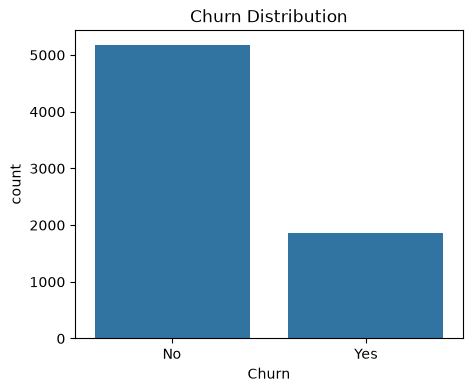

In [14]:
plt.figure(figsize=(5,4))
sns.countplot(data = df, x= 'Churn')
plt.title('Churn Distribution')
plt.show()

In [15]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


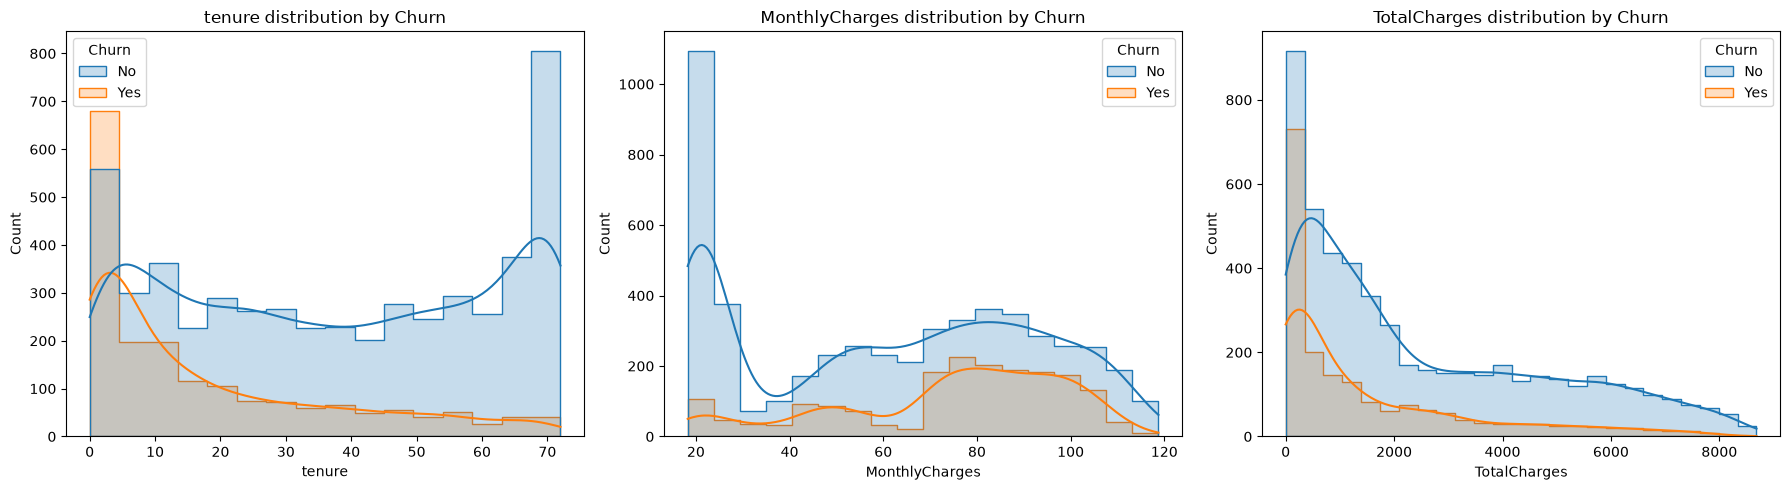

In [16]:
fig , axes = plt.subplots(1,3, figsize=(18,5))

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde= True, ax = axes[i], element = 'step')
    axes[i].set_title(f'{col} distribution by Churn')

plt.tight_layout()
plt.show()

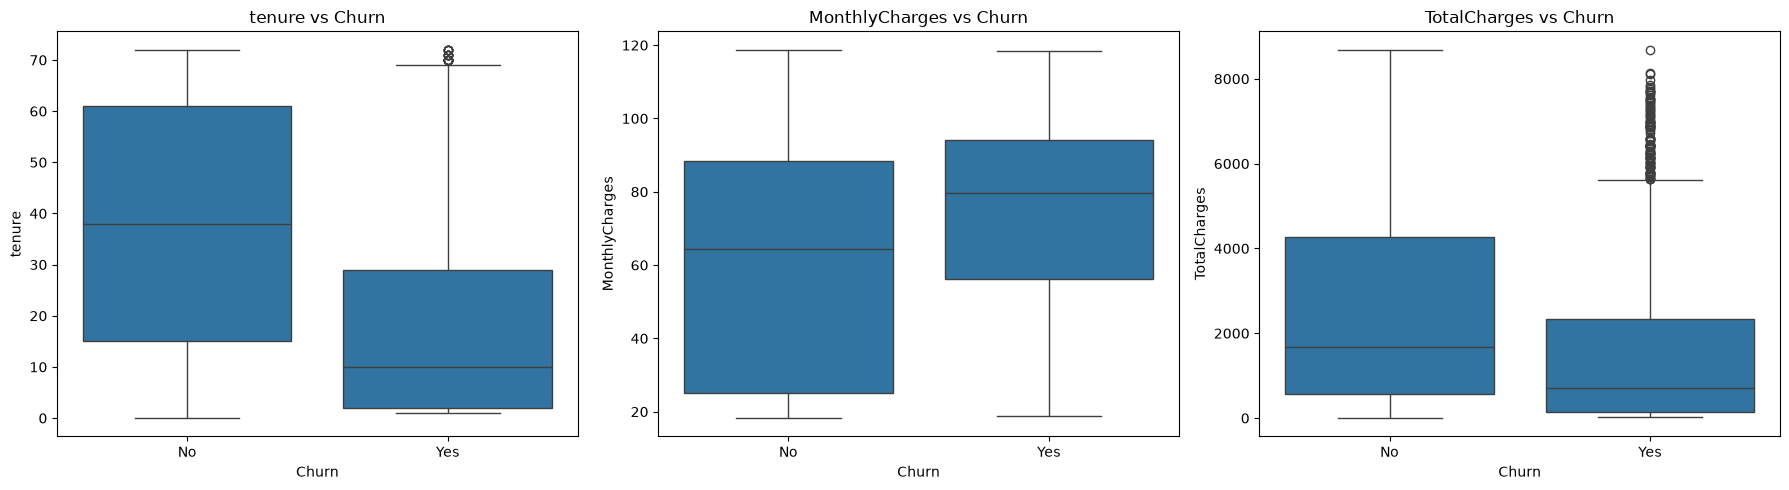

In [17]:
fig ,axes = plt.subplots(1,3 , figsize = (18,5))

for i, col in enumerate(num_cols):
    sns.boxplot(data = df, x = 'Churn', y = col , ax =axes[i])
    axes[i].set_title(f"{col} vs Churn")

plt.tight_layout()
plt.show()

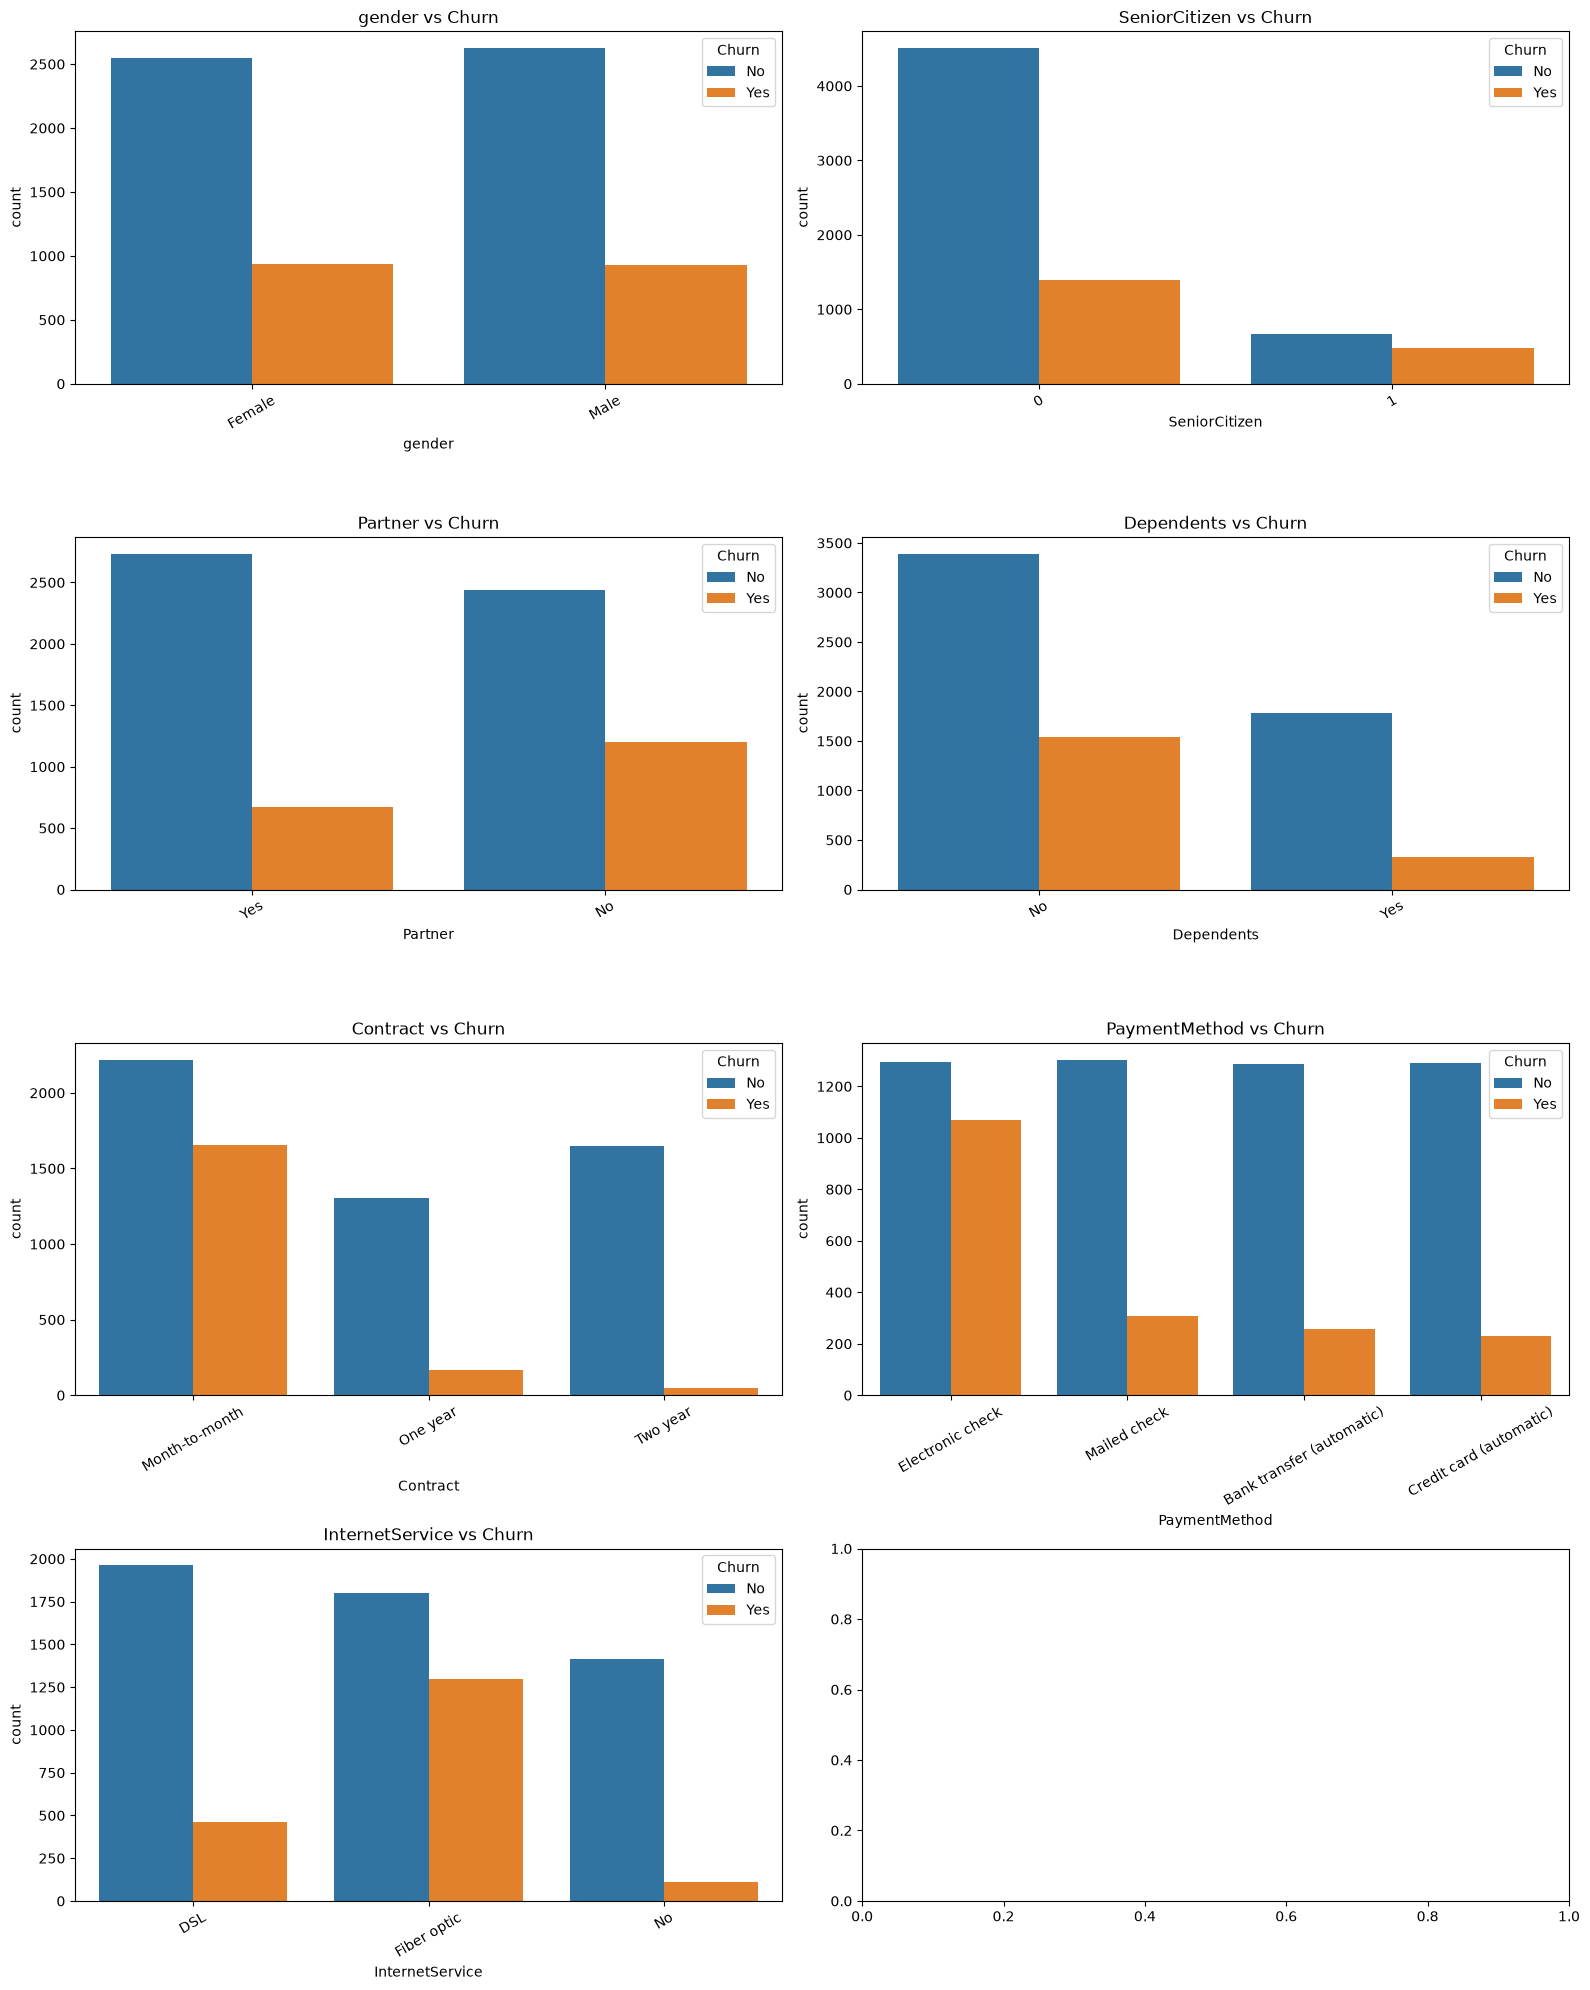

In [18]:
cat_cols_to_plot = ['gender' , 'SeniorCitizen', 'Partner', 'Dependents', 'Contract', 'PaymentMethod', 'InternetService']

fig , axes = plt.subplots(4,2, figsize = (16,20))
axes = axes.flatten()

for i, col in enumerate(cat_cols_to_plot):
    sns.countplot(data =df , x = col , hue = 'Churn', ax = axes[i])
    axes[i].set_title(f"{col} vs Churn")
    axes[i].tick_params(axis = 'x' , rotation = 30)

plt.tight_layout()
plt.show()

In [19]:
churn_by_contract = df.groupby('Contract')['Churn'].apply(lambda x : (x == 'Yes').mean() *100)
churn_by_contract.sort_values(ascending = False)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

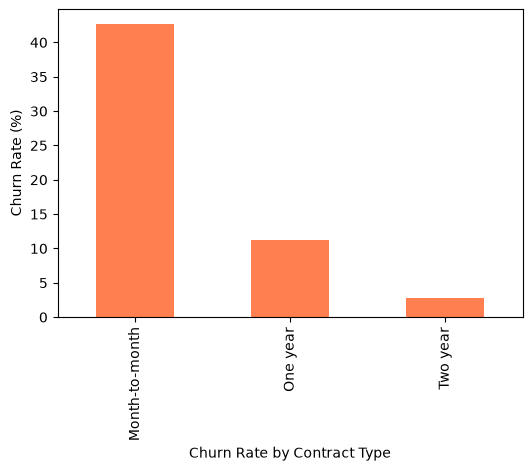

In [20]:
churn_by_contract.plot(kind = 'bar', figsize=(6,4), color = 'coral')
plt.ylabel('Churn Rate (%)')
plt.xlabel("Churn Rate by Contract Type")

plt.show()

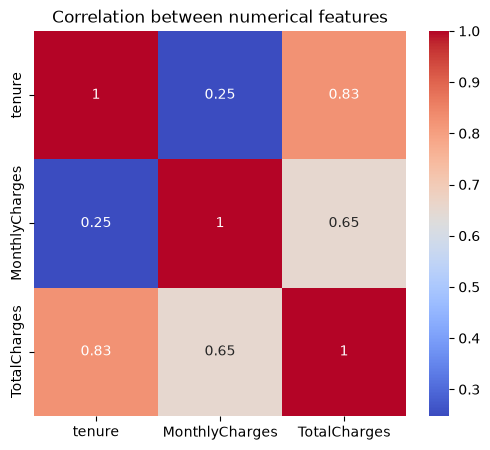

In [21]:
plt.figure(figsize=(6,5))
corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
sns.heatmap(df[corr_cols].corr(), annot = True, cmap = 'coolwarm')
plt.title('Correlation between numerical features')
plt.show()

### EDA Insights

- Churn is highest among customers with **low tenure** - newer customers are far more likely to leave than long--ones. This suggest the first few months are critical for retention efforts.
- **Month-to-Month contracts** have a much higher churn rate compared to 1--year or 2--year contracts - customers on longer contracts are effectively locked in and less likely to leave.
- **Fiber optic internet** customers churn more than DSL customers, despite (presumably) paying more for a better service — worth flagging as something to investigate further (could be pricing, service reliability, or competition).
- Customers paying via **electronic check** churn more than those on automatic payment methods — could reflect less "sticky" customers overall (manual payment = lower switching friction).
- `MonthlyCharges` tends to be higher for churned customers, while `TotalCharges` tends to be lower — this actually makes sense together: churners often have short tenure (fewer months billed) but higher rates, so total spend stays low despite high monthly cost.

## Feature Engineering

Encoding categorical variables, simplyfying redundant categories, and preparing features for modeling

In [22]:
cols_to_simplyify = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV','StreamingMovies']

for col in cols_to_simplyify:
    df[col] = df[col].replace({'No internet service' : 'No'})

df['MultipleLines'] = df['MultipleLines'].replace({'No phone service' : 'No'})

In [23]:
X = df.drop('Churn', axis = 1)
y = df['Churn'].map({'Yes' : 1, 'No' : 0})

In [24]:
binary_cols = [col for col in X.columns if X[col].nunique() == 2]
multi_cat_cols = [col for col in X.select_dtypes(include = 'object').columns if col not in binary_cols]
numeric_cols = X.select_dtypes(include = ['int64', 'float64']).columns.tolist()

print('Binary columns :', binary_cols)
print('Multi-Category columns : ', multi_cat_cols)
print('Numeric columns : ', numeric_cols)

Binary columns : ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling']
Multi-Category columns :  ['InternetService', 'Contract', 'PaymentMethod']
Numeric columns :  ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


C:\Users\NIKHIL KUMAR\AppData\Local\Temp\ipykernel_25200\174300020.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  multi_cat_cols = [col for col in X.select_dtypes(include = 'object').columns if col not in binary_cols]


In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in binary_cols:
    X[col] = le.fit_transform(X[col])

In [26]:
X = pd.get_dummies(X, columns=multi_cat_cols, drop_first=True)
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,1,29.85,29.85,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,0,56.95,1889.50,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,1,53.85,108.15,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,0,42.30,1840.75,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,1,70.70,151.65,True,False,False,False,False,True,False


In [27]:
print('Shape after encoding :', X.shape)

Shape after encoding : (7043, 23)


## Train-Test-Split

Splitting data before any scaling or balancing, to avoid data leakage

In [28]:
from sklearn.model_selection import train_test_split

X_train , X_test, y_train , y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print("X_train shape :", X_train.shape)
print("X_test_shape :", X_test.shape)

X_train shape : (5634, 23)
X_test_shape : (1409, 23)


In [29]:
print("Train churn rate :", y_train.mean())
print("Test churn rate :", y_test.mean())

Train churn rate : 0.2653532126375577
Test churn rate : 0.2654364797728886


### Split Notes

Used an 80/20 split with stratification on **Churn** to preserve the class ratio in both train and test sets. This ensures the test set is a fair representation of the real churn rate, so evaluation metrics aren't skewed by an unlucky split.

## Feature Scaling & Class Imbalance

Scaling numeric features and addressing class imbalance - both done strictly after thetrain-test-split, fit on training data only.

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [31]:
from imblearn.over_sampling import SMOTE

print('Before SMOTE:', y_train.value_counts())

smote = SMOTE(random_state = 42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train , y_train)

print('After SMOTE: ', y_train_resampled.value_counts())

Before SMOTE: Churn
0    4139
1    1495
Name: count, dtype: int64
After SMOTE:  Churn
0    4139
1    4139
Name: count, dtype: int64


### Scaling & Imbalance Notes

- Scaled tenure, MonthlyCharges, and  TotalCharges using StandardScaler, fit only on training data to avoid leakage.
- Applied SMOTE only to the training set to balance the churn classes (~26/74 → 50/50), so the model isn't biased toward predicting "No Churn" by default.
- Kept the test set untouched and imbalanced — it needs to reflect real-world distribution so evaluation metrics are meaningful.
- Will compare model performance with and without SMOTE, and also try class_weight='balanced' as an alternative approach, to see which works better for this dataset.

## Model Building

Training baseline and advanced models, comparing SMOTE vs class_weight approaches for handling imbalance.

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [33]:
log_reg_smote = LogisticRegression(max_iter = 1000, random_state=42)
log_reg_smote.fit(X_train_resampled, y_train_resampled)

log_reg_cw = LogisticRegression(max_iter = 1000, class_weight = 'balanced', random_state = 42)
log_reg_cw.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [34]:
rf_smote = RandomForestClassifier(n_estimators = 200 , random_state = 42)
rf_smote.fit(X_train_resampled , y_train_resampled)

rf_cw = RandomForestClassifier(n_estimators = 200 ,class_weight='balanced', random_state = 42)
rf_cw.fit(X_train , y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [35]:
xgb_smote = XGBClassifier(random_state = 42, eval_metric = 'logloss')
xgb_smote.fit(X_train_resampled , y_train_resampled)

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_cw = XGBClassifier(random_state = 42, eval_metric = 'logloss', scale_pos_weight = scale_pos_weight)
xgb_cw.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [36]:
models = {
    'Logistic Regression (SMOTE)': log_reg_smote,
    'Logistic Regression (class_weight)': log_reg_cw,
    'Random Forest (SMOTE)': rf_smote,
    'Random Forest (class_weight)': rf_cw,
    'XGBoost (SMOTE)': xgb_smote,
    'XGBoost (class_weight)': xgb_cw,
}

for name, model in models.items():
    train_acc = model.score(X_train if 'class_weight' in name else X_train_resampled, 
                             y_train if 'class_weight' in name else y_train_resampled)
    print(f"{name} — training accuracy: {train_acc:.4f}")

Logistic Regression (SMOTE) — training accuracy: 0.7961
Logistic Regression (class_weight) — training accuracy: 0.7535
Random Forest (SMOTE) — training accuracy: 0.9987
Random Forest (class_weight) — training accuracy: 0.9950
XGBoost (SMOTE) — training accuracy: 0.9385
XGBoost (class_weight) — training accuracy: 0.9272


### Model building Notes

Trained three models - Logistic Regression , Random Forest and XGBoost - each in two versions: one trained on SMOTE-balanced data, one trained on the original data using class weighting

Training accuracy above is just a sanity check that models fit without errors — actual comparison will use recall, F1, and ROC-AUC on the test set in the next step, since that's what actually matters for this problem.

## Model Evaluation

Comapring all models on the test using recall, F1-score and ROC-AUC -- since accuracy alone is misleading for this imbalanced problem

In [37]:
from sklearn.metrics import (classification_report , confusion_matrix,
                        roc_auc_score, f1_score, recall_score, precision_score, )

In [38]:
def evaluate_model(name , model , X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test , y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test , y_proba)

    return {
        'Model': name,
        'Recall': recall,
        'Precision': precision,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

In [39]:
results = []
for name, model in models.items():
    results.append(evaluate_model(name, model , X_test , y_test))

results_df = pd.DataFrame(results).sort_values(by ='Recall', ascending = False)
results_df

,Model,Recall,Precision,F1-Score,ROC-AUC
1,Logistic Regression (class_weight),0.783422,0.505172,0.614256,0.841951
0,Logistic Regression (SMOTE),0.732620,0.526923,0.612975,0.831517
5,XGBoost (class_weight),0.679144,0.552174,0.609113,0.821040
4,XGBoost (SMOTE),0.652406,0.543430,0.592953,0.818603
3,Random Forest (class_weight),0.649733,0.570423,0.607500,0.827461
2,Random Forest (SMOTE),0.631016,0.557920,0.592221,0.823527


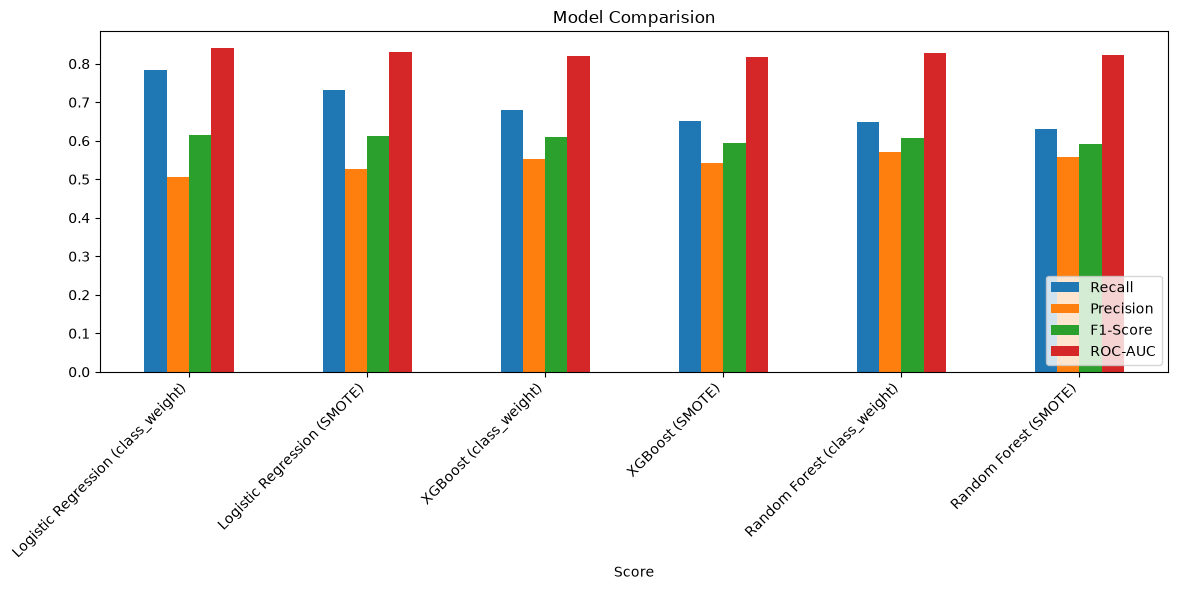

In [40]:
results_df.set_index('Model')[['Recall', 'Precision', 'F1-Score','ROC-AUC']].plot(
    kind='bar', figsize=(12,6)
)

plt.title('Model Comparision')
plt.xlabel('Score')
plt.xticks(rotation = 45, ha ='right')
plt.legend(loc= 'lower right')
plt.tight_layout()
plt.show()

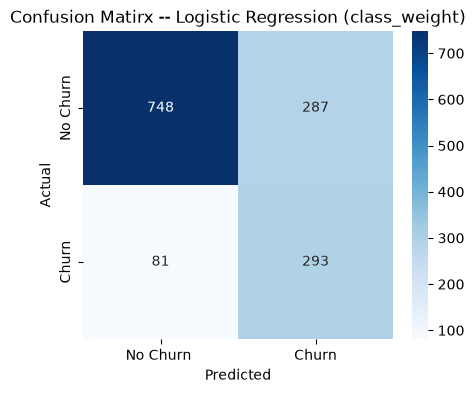

In [41]:
best_model = log_reg_cw

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize = (5,4))
sns.heatmap(cm , annot = True, fmt = 'd', cmap = 'Blues', 
           xticklabels = ['No Churn ', 'Churn'], yticklabels = ['No Churn', 'Churn']
           )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matirx -- Logistic Regression (class_weight)')
plt.show()

In [42]:
print(classification_report(y_test , y_pred_best , target_names = ['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



### Evaluation Notes

- **Best model: Logistic Regression (class_weight='balanced')** — chosen for having the highest recall (0.78) and ROC-AUC (0.84) among all 6 models tested.
- Across every model type, using `class_weight='balanced'` on the original data outperformed training on SMOTE-resampled data for recall — suggesting SMOTE's synthetic samples didn't generalize as well as simply reweighting the loss on real examples.
- The simplest model (Logistic Regression) outperformed both Random Forest and XGBoost on recall/ROC-AUC — suggesting the churn signal in this dataset is largely linear/additive rather than requiring complex non-linear interactions.
- Precision on the churn class is low (0.51) — about half of the customers flagged as "at risk" are false alarms. This is an accepted trade-off given the business priority (catching churners matters more than avoiding false alerts), but worth flagging as a real limitation.
- Overall accuracy (0.74) is nearly identical to a naive baseline that always predicts "No Churn" — reinforcing the Step 1 point that accuracy alone would have been a misleading metric for this problem. What matters is that this model actually identifies the churners, not just overall correctness.

## Hyparameter Tuning

Tuning Logistic Regression using GridSearchCV, optimizing for recall since that's the priority metric establised 

In [43]:
from sklearn.model_selection import GridSearchCV

In [44]:
param_grid = {
    'C' : [0.01, 0.1, 1, 10, 100],
    'penalty' : ['l1', 'l2'],
    'solver' : ['liblinear']
}

log_reg_base = LogisticRegression(class_weight = 'balanced', max_iter = 1000, random_state = 42)

In [45]:
grid_search = GridSearchCV(
    estimator = log_reg_base,
    param_grid= param_grid,
    scoring = 'recall',
    cv = 5,
    n_jobs = -1
)

grid_search.fit(X_train , y_train)

print("Best Parameters L ", grid_search.best_params_)
print("Best cross-validated recall :", grid_search.best_score_)

Best Parameters L  {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validated recall : 0.8046822742474916


D:\6th sem\Distributed Systems\envs\churn_project\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
D:\6th sem\Distributed Systems\envs\churn_project\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [46]:
best_log_reg = grid_search.best_estimator_

y_pred_tuned = best_log_reg.predict(X_test)
y_proba_tuned = best_log_reg.predict_proba(X_test)[:,1]

print("Tuned Model Performance on Test Set:")
print(classification_report(y_test, y_pred_tuned, target_names=['No Churn', 'Churn']))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_tuned))

Tuned Model Performance on Test Set:
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8421555710558267


In [47]:
comparison = pd.DataFrame({
    'Metric': ['Recall', 'Precision', 'F1-Score', 'ROC-AUC'],
    'Before Tuning': [0.783422, 0.505172, 0.614256, 0.841951],  # from your Step 9 results
    'After Tuning': [
        recall_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned),
        roc_auc_score(y_test, y_proba_tuned)
    ]
})
comparison

,Metric,Before Tuning,After Tuning
0,Recall,0.783422,0.788770
1,Precision,0.505172,0.504274
2,F1-Score,0.614256,0.615224
3,ROC-AUC,0.841951,0.842156


### Tuning Notes

- Used GridSearchCV with 5-fold cross-validation, optimizing for recall.
- Best parameters: C=1, penalty='l1', solver='liblinear'
- Cross-validated recall during tuning: 0.805
- Test set performance after tuning: Recall 0.789 (vs 0.783 untuned), F1 0.615 (vs 0.614), ROC-AUC 0.842 (vs 0.842)
- Improvement from tuning was marginal across all metrics — suggesting the default Logistic Regression was already close to its performance ceiling given the current feature set. Further gains would likely require better features rather than more tuning on this model.
- Will proceed with the tuned model (`best_log_reg`) as the final model, since it's marginally better and the l1 penalty may have also simplified the feature set slightly.

## Model Interpretation 

Understanding which features drive churn prediction - using both logistic regression coefficients and SHAP values.

In [48]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_log_reg.coef_[0]
}).sort_values(by = 'Coefficient', ascending = False)

coefficients

,Feature,Coefficient
16,InternetService_Fiber optic,0.771633
15,TotalCharges,0.480464
21,PaymentMethod_Electronic check,0.390546
13,PaperlessBilling,0.331498
12,StreamingMovies,0.237640
6,MultipleLines,0.230136
11,StreamingTV,0.212303
1,SeniorCitizen,0.056897
22,PaymentMethod_Mailed check,0.028883
0,gender,0.024272


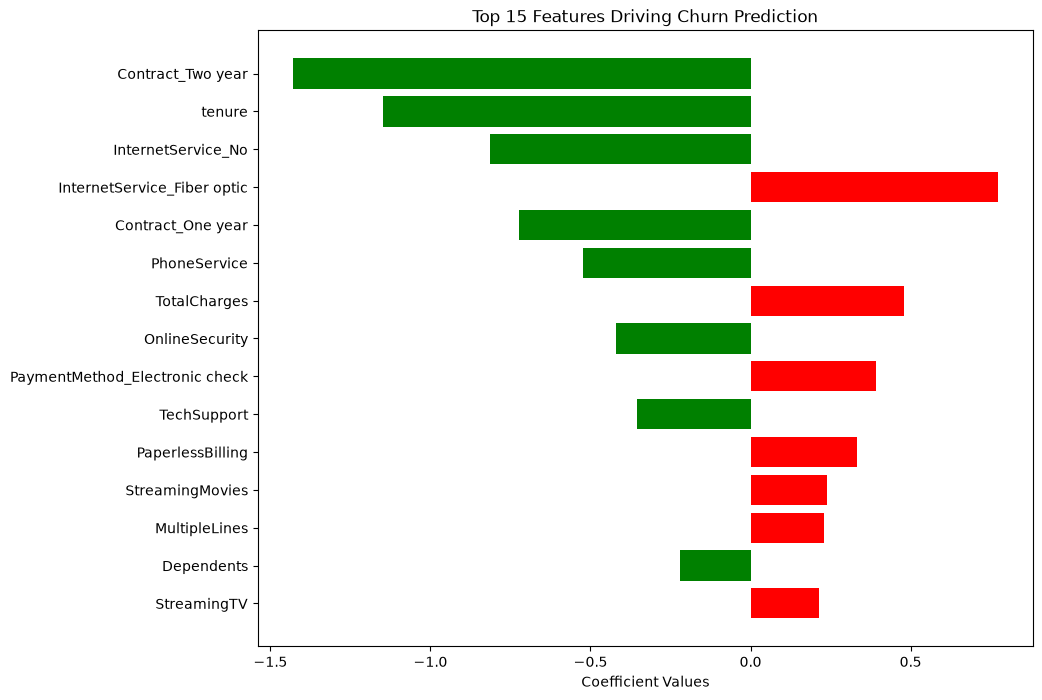

In [49]:
plt.figure(figsize = (10,8))
top_features = coefficients.reindex(coefficients.Coefficient.abs().sort_values(ascending = False).index).head(15)

colors = ['red' if c > 0 else 'green' for c in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color = colors)
plt.xlabel('Coefficient Values')
plt.title('Top 15 Features Driving Churn Prediction')
plt.gca().invert_yaxis()
plt.show()

In [52]:
import shap

explainer = shap.LinearExplainer(best_log_reg, X_train)
shap_values = explainer.shap_values(X_test)

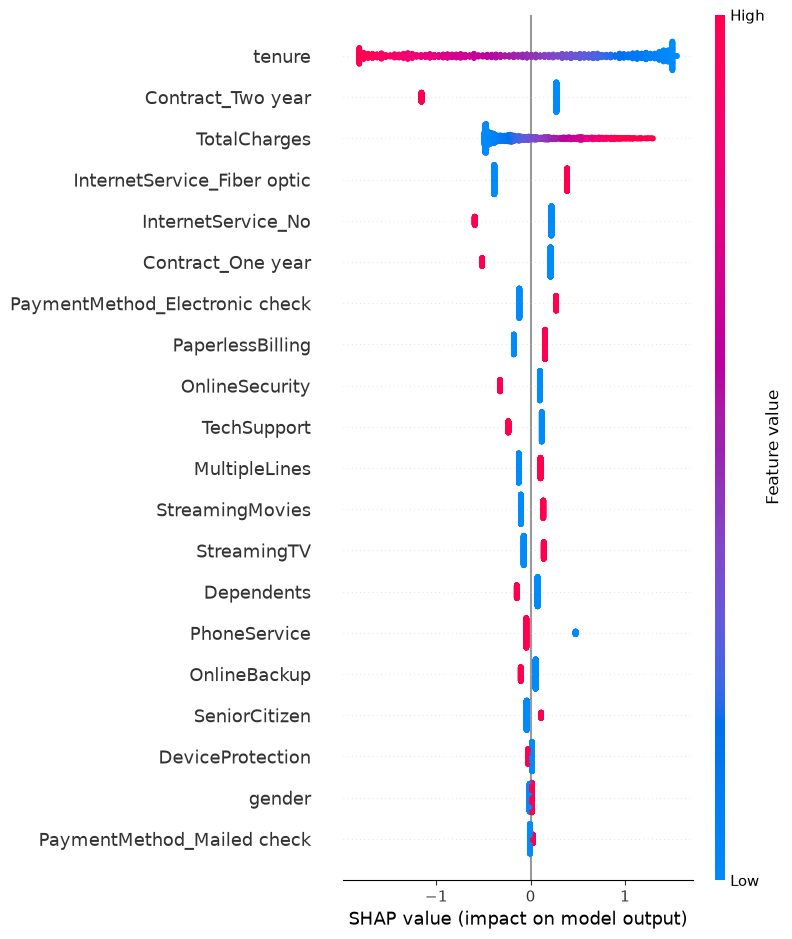

In [54]:
X_train_shap = X_train.astype(float)
X_test_shap = X_test.astype(float)

explainer = shap.LinearExplainer(best_log_reg , X_train_shap)
shap_values = explainer.shap_values(X_test_shap)

shap.summary_plot(shap_values, X_test_shap, feature_names= X_train_shap.columns)

## Deployment Prep

Saving the trained model, scaler, and column structure so they can be used outside this notebook - specifically, in a Streamlit app for deployment.

In [56]:
import joblib

joblib.dump(best_log_reg , 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X_train.columns.tolist(), 'model_column.pkl')

['model_column.pkl']

Saved 3 artifacts:
- `churn_model.pkl` — the final tuned Logistic Regression model
- `scaler.pkl` — fitted StandardScaler for numeric features (tenure, MonthlyCharges, TotalCharges)
- `model_columns.pkl` — exact column names/order the model expects, used to align new input data before prediction

In [2]:
import os
os.rename('model_column.pkl', 'model_columns.pkl')

In [3]:
print([f for f in os.listdir() if f.endswith('.pkl')])

['churn_model.pkl', 'model_columns.pkl', 'scaler.pkl']
